# Workshop-2
## Car Price Prediction

**Module:** Big Data, 6CS030

**Institution:** Herald College Kathmandu

**Submitted Date:** March 16, 2026


---

### Student Details

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |
| **Shreya Gurung** | 2418794 | L6CG15 |
| **Diksha Maharjan** | 2408235 | L6CG15 |

---

<div style="display: flex; justify-content: space-between; align-items: center; border: none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="
  https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>


# Model Implementation

In [21]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
print("Libraries loaded successfully")


Libraries loaded successfully


## Load Dataset


In [22]:
import kagglehub, os

path = kagglehub.dataset_download("nalisha/car-price-prediction-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   File: {csv_file}")


Using Colab cache for faster access to the 'car-price-prediction-dataset' dataset.
Dataset loaded: 2,500 rows × 10 columns
   File: car_price_prediction_with_missing.csv


## Dataset Overview


In [23]:
print("=" * 55)
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Duplicates  : {df.duplicated().sum()}")
print(f"  Memory      : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 55)
df.head(10)


  Rows        : 2,500
  Columns     : 10
  Duplicates  : 249
  Memory      : 738.9 KB


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang
5,6.0,Audi,2019.0,2.4,Diesel,Automatic,246553.0,Like New,88969.76,Q7
6,7.0,Audi,2020.0,4.0,Electric,Automatic,135486.0,Used,63498.75,Q5
7,8.0,Tesla,2017.0,5.3,Hybrid,Automatic,83030.0,New,17381.19,Model Y
8,9.0,Honda,2023.0,5.7,Electric,Manual,120360.0,Like New,15905.62,Civic
9,10.0,Ford,2010.0,1.5,Electric,Automatic,135009.0,Like New,9560.22,Explorer


In [24]:
# Data types summary
type_summary = pd.DataFrame(
    {
        "Data Type": df.dtypes,
        "Non-Null": df.notnull().sum(),
        "Null Count": df.isnull().sum(),
        "Null %": (df.isnull().sum() / len(df) * 100).round(2),
        "Unique Values": df.nunique(),
    }
)
print(type_summary.to_string())


             Data Type  Non-Null  Null Count  Null %  Unique Values
Car ID         float64      2250         250    10.0           2250
Brand           object      2250         250    10.0              7
Year           float64      2250         250    10.0             24
Engine Size    float64      2250         250    10.0             51
Fuel Type       object      2250         250    10.0              4
Transmission    object      2250         250    10.0              2
Mileage        float64      2250         250    10.0           2242
Condition       object      2250         250    10.0              3
Price          float64      2250         250    10.0           2249
Model           object      2250         250    10.0             28


## Exploratory Data Analysis

Columns with null values: ['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'Model']


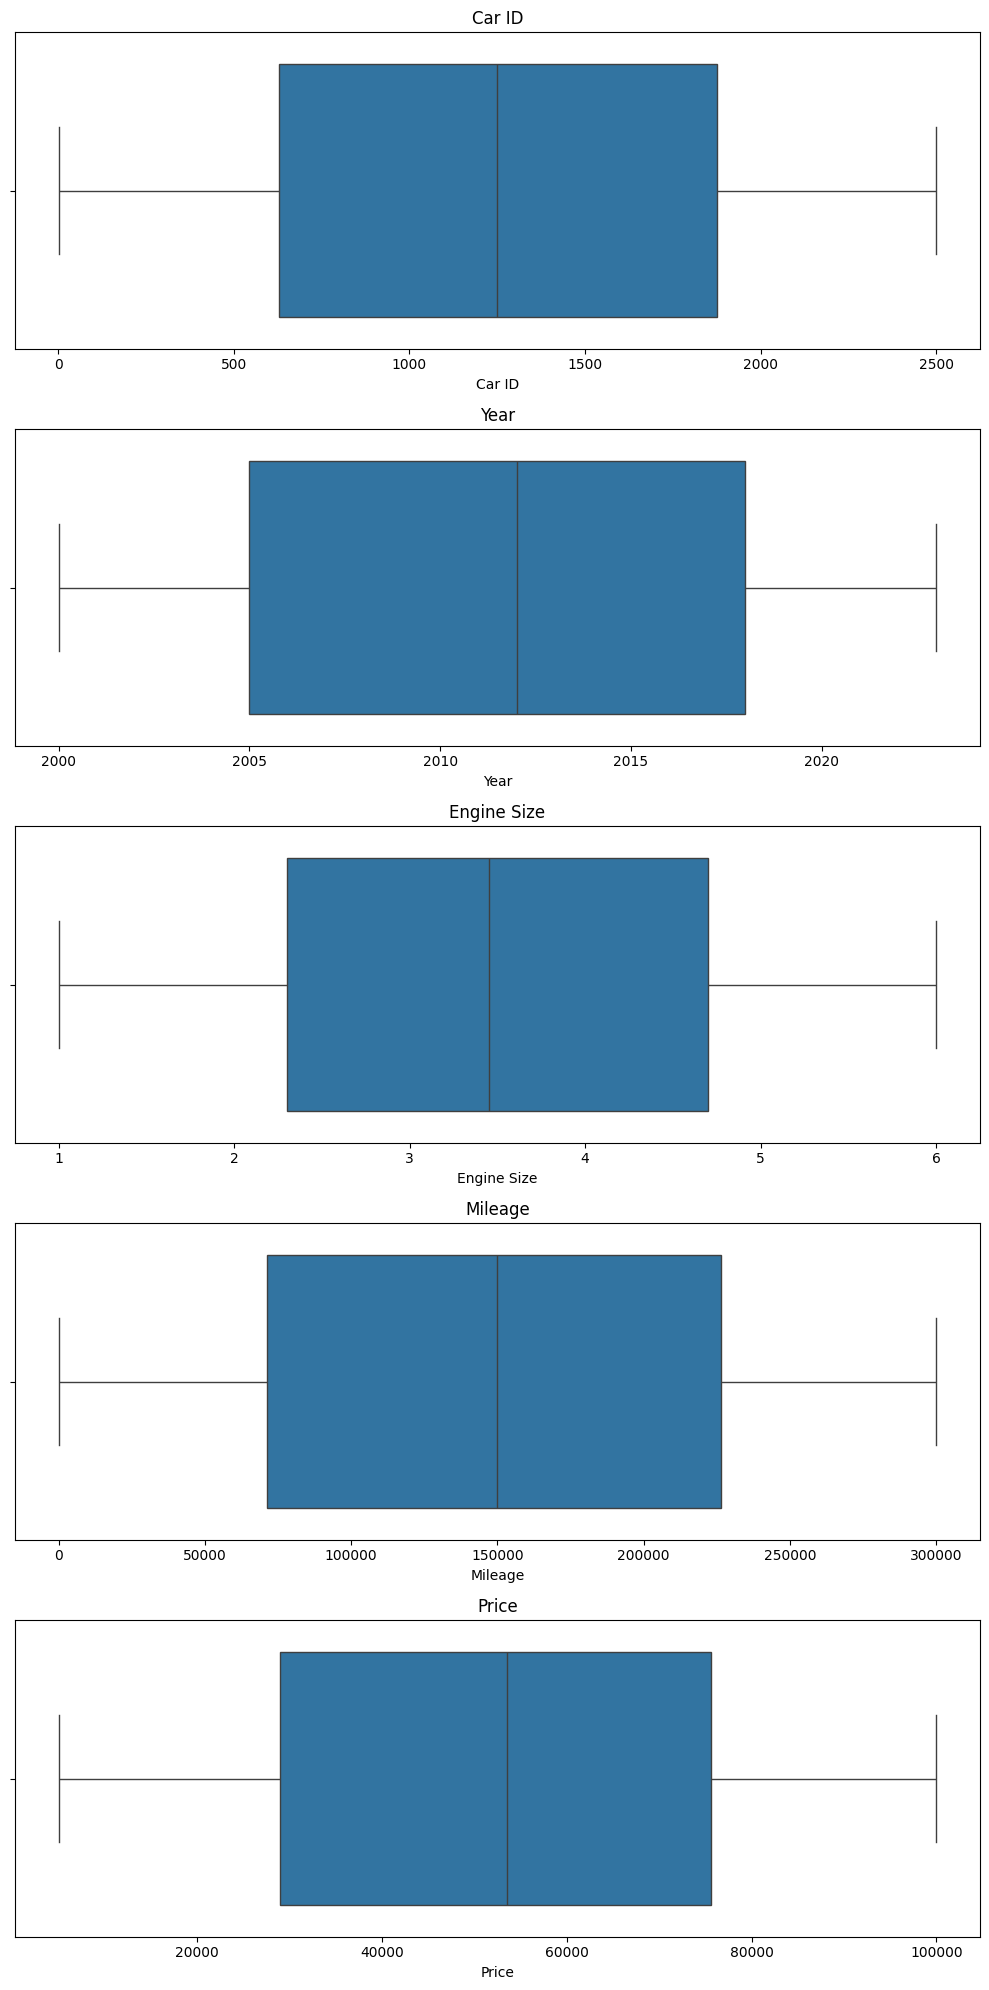

In [25]:
column_with_nulls = df.columns[df.isnull().any()].tolist()
print(f"Columns with null values: {column_with_nulls}")

numeric_null_columns = [
    col for col in column_with_nulls if pd.api.types.is_numeric_dtype(df[col])
]

if not numeric_null_columns:
    print("No numerical columns with null values found to plot.")
else:
    fig, axes = plt.subplots(
        len(numeric_null_columns), 1, figsize=(10, 4 * len(numeric_null_columns))
    )
    if len(numeric_null_columns) == 1:
        axes = [axes]

    for i, col in enumerate(numeric_null_columns):
        sns.boxplot(x=df[col].dropna(), ax=axes[i])
        axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [26]:
# ── Handle Missing Values ─────────────────────────────────────────────────
# Since we have 10% missing values in all columns, we'll drop them
print(f"\nOriginal shape: {df.shape}")
df.dropna(inplace=True)
print(f"Shape after dropping nulls: {df.shape}")



Original shape: (2500, 10)
Shape after dropping nulls: (2250, 10)


In [27]:
# ── Remove Duplicates ────────────────────────────────────────────────────
print(f"Duplicates before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after: {df.duplicated().sum()}")
print(f"Final shape: {df.shape}")


Duplicates before: 0
Duplicates after: 0
Final shape: (2250, 10)


In [28]:
print("\n── Numeric Summary ──")
display(df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"]))

print("\n── Categorical Summary ──")
display(df.describe(include="object").T)



── Numeric Summary ──


,count,mean,std,min,25%,50%,75%,max
Car ID,2250.000000,1251.243556,725.637358,1.000000,627.250000,1249.500000,1875.250000,2500.000000
Year,2250.000000,2011.577778,6.980468,2000.000000,2005.000000,2012.000000,2018.000000,2023.000000
Engine Size,2250.000000,3.485467,1.427690,1.000000,2.300000,3.450000,4.700000,6.000000
Mileage,2250.000000,150236.178222,88150.746556,15.000000,71178.500000,149762.000000,226299.000000,299967.000000
Price,2250.000000,52506.874391,27232.417079,5011.270000,28985.052500,53485.240000,75560.340000,99982.590000



── Categorical Summary ──


,count,unique,top,freq
Brand,2250,7,Toyota,346
Fuel Type,2250,4,Diesel,587
Transmission,2250,2,Manual,1184
Condition,2250,3,Used,769
Model,2250,28,Corolla,97


here, in above box plot, whiskers seem to be roughly similar in both sides, hence, we can say that data is apporximately symmetric, and also median seems to be near the center of the box, giving an affirmative signal to use mean to fill the missing values in the dataset.

but since we have 2500 rows, and the requirement is o ly 1000 plus, we can drop it too so drop it

In [29]:
df.dropna(inplace=True)
print(f"Rows after dropping nulls: {df.shape[0]:,} rows")
print(f"Null values remaining: {df.isnull().sum().sum()}")


Rows after dropping nulls: 2,250 rows
Null values remaining: 0


In [30]:
# Data types summary
type_summary = pd.DataFrame(
    {
        "Data Type": df.dtypes,
        "Non-Null": df.notnull().sum(),
        "Null Count": df.isnull().sum(),
        "Null %": (df.isnull().sum() / len(df) * 100).round(2),
        "Unique Values": df.nunique(),
    }
)
print(type_summary.to_string())


             Data Type  Non-Null  Null Count  Null %  Unique Values
Car ID         float64      2250           0     0.0           2250
Brand           object      2250           0     0.0              7
Year           float64      2250           0     0.0             24
Engine Size    float64      2250           0     0.0             51
Fuel Type       object      2250           0     0.0              4
Transmission    object      2250           0     0.0              2
Mileage        float64      2250           0     0.0           2242
Condition       object      2250           0     0.0              3
Price          float64      2250           0     0.0           2249
Model           object      2250           0     0.0             28


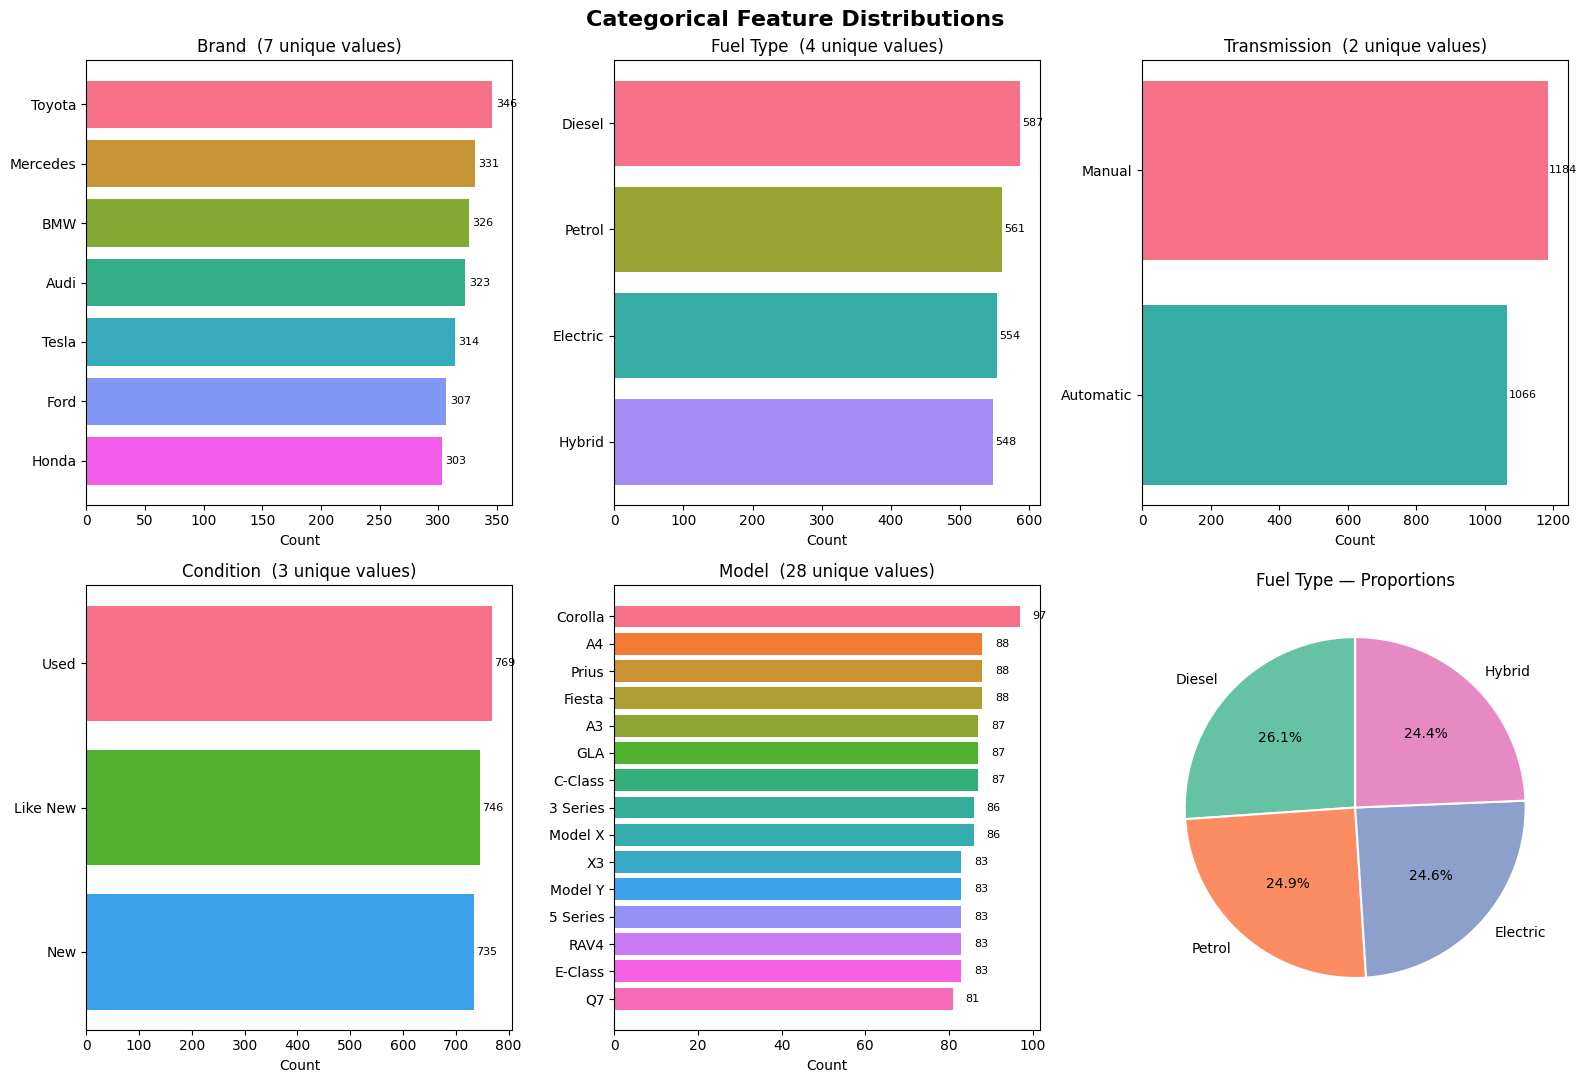

In [31]:
cat_cols = ["Brand", "Fuel Type", "Transmission", "Condition", "Model"]

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle("Categorical Feature Distributions", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts().head(15)
    bars = axes[i].barh(vc.index, vc.values, color=sns.color_palette("husl", len(vc)))
    axes[i].set_title(f"{col}  ({df[col].nunique()} unique values)")
    axes[i].invert_yaxis()
    axes[i].set_xlabel("Count")
    for bar, val in zip(bars, vc.values):
        axes[i].text(
            bar.get_width() + 3,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            fontsize=8,
        )

# Pie chart: Fuel Type
ft = df["Fuel Type"].value_counts()
axes[5].pie(
    ft.values,
    labels=ft.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2"),
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
axes[5].set_title("Fuel Type — Proportions")

plt.tight_layout()
plt.show()


## Feature Enginnering

In [32]:
# ── Feature Engineering ───────────────────────────────────────────────────
# Create new features
current_year = 2024
df["car_age"] = current_year - df["Year"]
df["mileage_per_year"] = df["Mileage"] / (
    df["car_age"] + 1
)  # Add 1 to avoid division by zero
df["engine_age_interaction"] = df["Engine Size"] * df["car_age"]
df["price_per_engine"] = df["Price"] / (df["Engine Size"] + 0.1)  # Add small constant

# Handle outliers in price (capping at 99th percentile)
price_upper = df["Price"].quantile(0.99)
price_lower = df["Price"].quantile(0.01)
df["Price"] = np.where(
    df["Price"] > price_upper,
    price_upper,
    np.where(df["Price"] < price_lower, price_lower, df["Price"]),
)

# Log transform the target (if skewed)
from scipy.stats import skew

price_skew = skew(df["Price"])
print(f"Price skewness: {price_skew:.2f}")

if abs(price_skew) > 1:
    df["Price_log"] = np.log1p(df["Price"])
    target_col = "Price_log"
    use_log_transform = True
    print("Using log-transformed price as target")
else:
    target_col = "Price"
    use_log_transform = False
    print("Using original price as target")


Price skewness: -0.02
Using original price as target


In [33]:
# ── Prepare Features for Modeling ─────────────────────────────────────────
# Drop ID column and original Year (we have car_age)
df.drop(["Car ID", "Year"], axis=1, inplace=True)

# Identify feature types
numeric_features = [
    "Engine Size",
    "Mileage",
    "car_age",
    "mileage_per_year",
    "engine_age_interaction",
]
categorical_features = ["Brand", "Fuel Type", "Transmission", "Condition"]

# Handle high-cardinality feature 'Model' with frequency encoding
model_freq = df["Model"].value_counts().to_dict()
model_freq_normalized = df["Model"].value_counts(normalize=True).to_dict()
df["Model_freq"] = df["Model"].map(model_freq)
df["Model_freq_norm"] = df["Model"].map(model_freq_normalized)
df.drop("Model", axis=1, inplace=True)

print(f"Final feature count: {df.shape[1]}")
print(f"Features: {df.columns.tolist()}")


Final feature count: 13
Features: ['Brand', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'car_age', 'mileage_per_year', 'engine_age_interaction', 'price_per_engine', 'Model_freq', 'Model_freq_norm']


In [34]:
df.head()


,Brand,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,car_age,mileage_per_year,engine_age_interaction,price_per_engine,Model_freq,Model_freq_norm
0,Tesla,2.3,Petrol,Manual,114832.0,New,26613.92,8.0,12759.111111,18.4,11089.133333,86,0.038222
1,BMW,4.4,Electric,Manual,143190.0,Used,14679.61,6.0,20455.714286,26.4,3262.135556,83,0.036889
2,Audi,4.5,Electric,Manual,181601.0,New,44402.61,11.0,15133.416667,49.5,9652.741304,88,0.039111
3,Tesla,4.1,Diesel,Automatic,68682.0,New,86374.33,13.0,4905.857143,53.3,20565.316667,83,0.036889
4,Ford,2.6,Diesel,Manual,223009.0,Like New,73577.10,15.0,13938.062500,39.0,27250.777778,73,0.032444


## Train Test Split

In [35]:
# ── Split Data ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df.drop([target_col, "Price"] if use_log_transform else [target_col], axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df["Brand"] if "Brand" in df.columns else None,
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (1800, 12)
Test set size: (450, 12)


## Create Pipeline

In [36]:
# ── Create Preprocessing Pipeline ─────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define preprocessing for different column types
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]
)

# Identify columns in the actual data
available_numeric = [col for col in numeric_features if col in X_train.columns]
available_categorical = [col for col in categorical_features if col in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, available_numeric),
        ("cat", categorical_transformer, available_categorical),
    ],
    remainder="passthrough",  # Keep other columns (like Model_freq)
)


## Cross-Validate with multiple models

In [37]:
# ── Try Multiple Models with Cross-Validation ─────────────────────────────
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create k-fold cross validator
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define models to try
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    ),
}


In [38]:
# Evaluate each model with cross-validation
results = {}
for name, model in models.items():
    # Create pipeline with preprocessor and model
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])

    # Perform cross-validation
    scores = cross_val_score(
        pipeline, X_train, y_train, cv=kfold, scoring="r2", n_jobs=-1
    )

    results[name] = {
        "mean_r2": scores.mean(),
        "std_r2": scores.std(),
        "pipeline": pipeline,
    }

    print(f"{name}: R² = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Select best model based on cross-validation
best_model_name = max(results, key=lambda x: results[x]["mean_r2"])
best_pipeline = results[best_model_name]["pipeline"]
print(
    f"\nBest model: {best_model_name} with R² = {results[best_model_name]['mean_r2']:.4f}"
)


Ridge: R² = 0.6881 (+/- 0.0781)
Lasso: R² = 0.6881 (+/- 0.0781)
ElasticNet: R² = 0.6881 (+/- 0.0781)
Random Forest: R² = 0.9956 (+/- 0.0017)
Gradient Boosting: R² = 0.9974 (+/- 0.0009)
XGBoost: R² = 0.9927 (+/- 0.0008)

Best model: Gradient Boosting with R² = 0.9974


## Hyperparameter Tuning for Best Model

In [39]:
# ── Hyperparameter Tuning for Best Model ──────────────────────────────────
from sklearn.model_selection import GridSearchCV

if best_model_name == "XGBoost":
    param_grid = {
        "regressor__n_estimators": [100, 200, 300],
        "regressor__max_depth": [3, 5, 7],
        "regressor__learning_rate": [0.05, 0.1, 0.15],
        "regressor__subsample": [0.7, 0.8, 0.9],
        "regressor__colsample_bytree": [0.7, 0.8, 0.9],
    }
elif best_model_name == "Random Forest":
    param_grid = {
        "regressor__n_estimators": [100, 200, 300],
        "regressor__max_depth": [5, 10, 15, None],
        "regressor__min_samples_split": [2, 5, 10],
        "regressor__min_samples_leaf": [1, 2, 4],
    }
elif best_model_name == "Gradient Boosting":
    param_grid = {
        "regressor__n_estimators": [100, 200, 300],
        "regressor__max_depth": [3, 5, 7],
        "regressor__learning_rate": [0.05, 0.1, 0.15],
        "regressor__subsample": [0.7, 0.8, 0.9],
    }
else:
    param_grid = {"regressor__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]}

# Perform grid search
grid_search = GridSearchCV(
    best_pipeline, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation R²: {grid_search.best_score_:.4f}")

# Use the best model
final_model = grid_search.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 7, 'regressor__n_estimators': 300, 'regressor__subsample': 0.7}
Best cross-validation R²: 0.9981


## Evaluating Model on Test Dataset


In [40]:
# ── Evaluate on Test Set ─────────────────────────────────────────────────
y_pred = final_model.predict(X_test)

# If we used log transform, convert back
if use_log_transform:
    y_test_original = np.expm1(y_test)
    y_pred_original = np.expm1(y_pred)
else:
    y_test_original = y_test
    y_pred_original = y_pred

# Calculate metrics
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_original)
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

print("\n" + "=" * 50)
print("FINAL MODEL PERFORMANCE ON TEST SET")
print("=" * 50)
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print("=" * 50)



FINAL MODEL PERFORMANCE ON TEST SET
Mean Absolute Error (MAE): $695.71
Root Mean Squared Error (RMSE): $1,088.08
R-squared (R²): 0.9983
Mean Absolute Percentage Error (MAPE): 1.59%
